# Notebook 01 — Dataset Exploration
## FYP: Adaptive Explainable Ensemble for Pre-Launch Steam Game Reception Prediction
### Heshan Ratnaweera | IIT Sri Lanka | W2082289 | 2026

**Purpose:** Comprehensive exploration of the raw Steam Games Dataset 2025 to understand structure, quality, and feature suitability before any modelling begins.  
**Inputs:** `data/raw/Dataset-2.csv`  
**Outputs:** `outputs/figures/01_*.png` (saved plots) — no data files written from this notebook  
**Key results:** *Not obtained yet*

---
## Contents
1. Setup & Imports  
2. Load Raw Dataset  
3. Basic Overview  
4. Null & Missing Value Analysis  
5. Column Decision Matrix — Keep / Drop / Fill  
6. Apply Filter & Create Label  
7. Numerical Feature Distributions  
8. Genre Analysis  
9. Tag Analysis  
10. Category Analysis  
11. Platform Coverage  
12. Price & Monetisation Analysis  
13. Developer Description Coverage  
14. Class Balance Deep Dive  
15. Feature–Label Correlation  
16. Findings Summary → `config.py` inputs


## 1. Setup & Imports

In [1]:
#Importing external libraries needed for the analysis
import pandas as pd #--pandas is used for data manipulation and analysis
import numpy as np #--numpy is used for numerical operations
import matplotlib.pyplot as plt #--matplotlib.pyplot is used for creating static, animated, and interactive visualizations in Python
import matplotlib.ticker as mticker #--matplotlib.ticker is used for customizing the tick labels on the axes of a plot
import seaborn as sns #--seaborn is used for statistical data visualization built on top of matplotlib
import ast #--ast (Abstract Syntax Trees) is used to parse Python code into a tree structure
import re #--re (regular expressions) is used for pattern matching and text manipulation
import os #--os is used for interacting with the operating system, such as file and directory operations
import warnings #--warnings is used to issue warning messages, which can be filtered and handled in various ways
from pathlib import Path #--Path from pathlib is used for handling file paths in a more object-oriented way
from collections import Counter #--Counter from collections is used for counting hashable objects, such as elements in a list or characters in a string

# BeautifulSoup — HTML parser; used to strip HTML tags from game descriptions
# The try/except block installs it automatically if it is not already installed
try:
    from bs4 import BeautifulSoup
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'beautifulsoup4', '-q'])
    from bs4 import BeautifulSoup

# Display Configuration
warnings.filterwarnings('ignore') #--ignore warnings
pd.set_option('display.max_columns', 60) #--display up to 60 columns
pd.set_option('display.max_colwidth', 80) #--display up to 80 characters per column
pd.set_option('display.float_format', '{:.4f}'.format) #--format floating-point numbers to 4 decimal places

sns.set_theme(style='darkgrid', palette='muted') #--set seaborn theme to darkgrid with muted color palette

# Directories for saving figures and models
FIGURES_DIR = Path('../outputs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True) #--create figures directory if it doesn't exist and create parent directories if they don't exist.

# Random state for reproducibility
RANDOM_STATE = 42
print('All imports OK')

All imports OK


In [2]:
import sys #--to check if the kernel is using the python installed in the venv : "fenv"
print(sys.executable) #--print the path of the Python executable being used in the kernel

C:\Users\3214h\Documents\fyp-steam-reception\fenv\Scripts\python.exe


## 2. Load Raw Dataset

> **Dataset:** Steam Games Dataset 2025 — Ermilov, S. (2025), Kaggle (artermiloff)  
> Downloaded from: https://www.kaggle.com/datasets/artermiloff/steam-games-dataset  
> File: `games_march2025_cleaned.csv` — placed at `data/raw/`  
> Renamed to: Dataset-2.csv


In [3]:
RAW_PATH = Path('../data/raw/Dataset-2.csv') #--path to the raw dataset file

# Check if the dataset file exists at the specified path
assert RAW_PATH.exists(), (
    f'Dataset not found at {RAW_PATH}. '
    'Download from Kaggle and place at data/raw/Dataset-2.csv'
)

df_raw = pd.read_csv(RAW_PATH, low_memory=False) #--read the dataset into a pandas DataFrame
print(f'Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns') #--print the number of rows and columns in the loaded dataset 
print(f'Memory usage: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB') #--print the memory usage of the DataFrame in megabytes

Loaded: 89,618 rows × 47 columns
Memory usage: 490.4 MB


## 3. Basic Overview

In [4]:
print('=== COLUMN LIST ===')
# Print the list of columns in the DataFrame along with their data types
for i, col in enumerate(df_raw.columns):
    print(f'  {i:>2}. {col:<40} dtype: {df_raw[col].dtype}')

=== COLUMN LIST ===
   0. appid                                    dtype: int64
   1. name                                     dtype: str
   2. release_date                             dtype: str
   3. required_age                             dtype: int64
   4. price                                    dtype: float64
   5. dlc_count                                dtype: int64
   6. detailed_description                     dtype: str
   7. about_the_game                           dtype: str
   8. short_description                        dtype: str
   9. reviews                                  dtype: str
  10. header_image                             dtype: str
  11. website                                  dtype: str
  12. support_url                              dtype: str
  13. support_email                            dtype: str
  14. windows                                  dtype: bool
  15. mac                                      dtype: bool
  16. linux                             

In [5]:
print('=== FIRST 3 ROWS (transposed for readability) ===')
df_raw.head(3).T #--transpose the first 3 rows for better readability

=== FIRST 3 ROWS (transposed for readability) ===


,0,1,2
appid,730,578080,570
name,Counter-Strike 2,PUBG: BATTLEGROUNDS,Dota 2
release_date,2012-08-21,2017-12-21,2013-07-09
required_age,0,0,0
price,0.0000,0.0000,0.0000
dlc_count,1,0,2
detailed_description,"For over two decades, Counter-Strike has offered an elite competitive experi...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS for free. Land on strategic lo...","The most-played game on Steam. Every day, millions of players worldwide ente..."
about_the_game,"For over two decades, Counter-Strike has offered an elite competitive experi...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS for free. Land on strategic lo...","The most-played game on Steam. Every day, millions of players worldwide ente..."
short_description,"For over two decades, Counter-Strike has offered an elite competitive experi...","Play PUBG: BATTLEGROUNDS for free. Land on strategic locations, loot weapons...","Every day, millions of players worldwide enter battle as one of over a hundr..."
reviews,NaN,NaN,“A modern multiplayer masterpiece.” 9.5/10 – Destructoid “Once you start to ...


In [6]:
print('=== BASIC STATISTICS — NUMERICAL COLUMNS ===')
df_raw.describe(include=[np.number]).T #--describe the dataset statistics for numerical columns and transpose the output for better readability

=== BASIC STATISTICS — NUMERICAL COLUMNS ===


,count,mean,std,min,25%,50%,75%,max
appid,89618.0000,1656903.9584,916838.9820,20.0000,855052.5000,1524730.0000,2430852.5000,3542350.0000
required_age,89618.0000,0.1836,1.7256,-1.0000,0.0000,0.0000,0.0000,21.0000
price,89618.0000,7.3096,13.3311,0.0000,0.9900,4.9900,9.9900,999.9800
dlc_count,89618.0000,0.5956,15.3519,0.0000,0.0000,0.0000,0.0000,3427.0000
metacritic_score,89618.0000,2.9032,14.4454,0.0000,0.0000,0.0000,0.0000,97.0000
achievements,89618.0000,20.5523,163.5624,0.0000,0.0000,5.0000,20.0000,9821.0000
recommendations,89618.0000,1009.4011,22048.1477,0.0000,0.0000,0.0000,0.0000,4401572.0000
user_score,89618.0000,0.0328,1.6151,0.0000,0.0000,0.0000,0.0000,100.0000
score_rank,39.0000,99.1282,0.6951,98.0000,99.0000,99.0000,100.0000,100.0000
positive,89618.0000,1269.8960,31814.4114,0.0000,1.0000,10.0000,58.0000,7480813.0000


In [7]:
print('=== BASIC STATISTICS — OBJECT COLUMNS ===')
df_raw.describe(include=['object']).T #--describe the dataset statistics for object columns and transpose the output for better readability

=== BASIC STATISTICS — OBJECT COLUMNS ===


,count,unique,top,freq
name,89618,88899,Alone,6
release_date,89618,4459,2024-10-31,141
detailed_description,89421,89075,Help the beautiful girls to immerse themselves in their memories and remembe...,58
about_the_game,89398,89040,Help the beautiful girls to immerse themselves in their memories and remembe...,58
short_description,89498,88586,Find the objects that are hidden on the map.,50
reviews,10401,10291,“ ” Read more on PC Gamer,21
header_image,89618,89587,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/750920/he...,5
website,41114,33321,https://www.facebook.com/8FloorGames/,247
support_url,44110,29309,https://www.facebook.com/8FloorGames,270
support_email,78798,48174,info@bigfishgames.com,314


## 4. Null & Missing Value Analysis

We check every column for:
- **NaN / None** (pandas null)
- **Empty strings** `''` (common in CSV exports)
- **Placeholder strings** like `'[]'`, `'unknown'`, `'N/A'`

All three are functionally missing and need separate handling.


In [8]:
# -----CUSTOM NULL AUDIT FUNCTION------------
# pandas .isna() only catches actual NaN values.
# But this dataset also has "functionally missing" values that aren't NaN:
#   - Empty strings ''       → a cell that exists but contains nothing
#   - Placeholders like '[]' → an empty list stored as a string
#   - 'none', 'null', 'n/a' → text that means "no data"
# We need to count all three types to get the true missing rate.

def audit_column(series):
    """Return null count, empty-string count, placeholder count, and sample values."""
    n = len(series) #--get the total number of raws in this column.
    n_null = series.isna().sum() #--count the number of null values(Actual NaN/None) in this column.
    n_empty = (series.astype(str).str.strip() == '').sum() - n_null #--count the number of empty strings in this column after stripping whitespace, removing n_null count to avoid double counting. .
    # Common placeholders for missing data (case-insensitive)
    placeholders = {'[]', '{}', 'none', 'null', 'n/a', 'na', 'unknown', 'nan'}
    n_placeholder = series.dropna().astype(str).str.strip().str.lower().isin(placeholders).sum() #--count the number of placeholder values in this column after dropping nulls, stripping whitespace, and converting to lowercase.
    pct_missing = (n_null + n_empty) / n * 100  # Percentage of this column that is effectively missing (null OR empty string)
    sample = series.dropna().iloc[:3].tolist() if n_null < n else [] #--get a sample of the first 3 non-null values in this column, or an empty list if all values are null.
    return {
        'dtype': str(series.dtype), #--get the data type of the column.
        'null': n_null, #--get the number of null values in this column.
        'empty_str': n_empty, #--get the number of empty strings in this column.
        'placeholder': n_placeholder, #--get the number of placeholder values in this column.
        'pct_missing': round(pct_missing, 2), # Percentage of this column that is effectively missing (null OR empty string)
        'n_unique': series.nunique(), #--get the number of distinct non-null values in this column.
        'sample': str(sample)[:80] # First 3 values, truncated to 80 chars
    }

# Audit all columns and sort by missing rate
audit = pd.DataFrame(
    {col: audit_column(df_raw[col]) for col in df_raw.columns}
).T.sort_values('pct_missing', ascending=False)

print(f'Total columns: {len(audit)}')
audit # Display the audit results

Total columns: 47


,dtype,null,empty_str,placeholder,pct_missing,n_unique,sample
appid,int64,0,0,0,0.0000,89618,"[730, 578080, 570]"
estimated_owners,str,0,0,0,0.0000,15,"['100000000 - 200000000', '50000000 - 100000000', '200000000 - 500000000']"
publishers,str,0,0,547,0.0000,49798,"[""['Valve']"", ""['KRAFTON, Inc.']"", ""['Valve']""]"
categories,str,0,0,876,0.0000,7471,"[""['Multi-player', 'Cross-Platform Multiplayer', 'Steam Trading Cards', 'Ste..."
genres,str,0,0,212,0.0000,2689,"[""['Action', 'Free To Play']"", ""['Action', 'Adventure', 'Massively Multiplay..."
screenshots,str,0,0,106,0.0000,89482,"[""['https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/730/s..."
movies,str,0,0,2411,0.0000,87183,"[""['http://video.akamai.steamstatic.com/store_trailers/256972298/movie_max.m..."
user_score,int64,0,0,0,0.0000,30,"[0, 0, 0]"
score_rank,float64,89579,-89579,0,0.0000,3,"[98.0, 99.0, 100.0]"
positive,int64,0,0,0,0.0000,5087,"[7480813, 1487960, 1998462]"


In [9]:
print(audit[['pct_missing']].astype(float).sort_values('pct_missing', ascending=False).head(20))

                          pct_missing
appid                          0.0000
estimated_owners               0.0000
publishers                     0.0000
categories                     0.0000
genres                         0.0000
screenshots                    0.0000
movies                         0.0000
user_score                     0.0000
score_rank                     0.0000
positive                       0.0000
negative                       0.0000
average_playtime_forever       0.0000
packages                       0.0000
average_playtime_2weeks        0.0000
median_playtime_forever        0.0000
median_playtime_2weeks         0.0000
discount                       0.0000
peak_ccu                       0.0000
tags                           0.0000
pct_pos_total                  0.0000


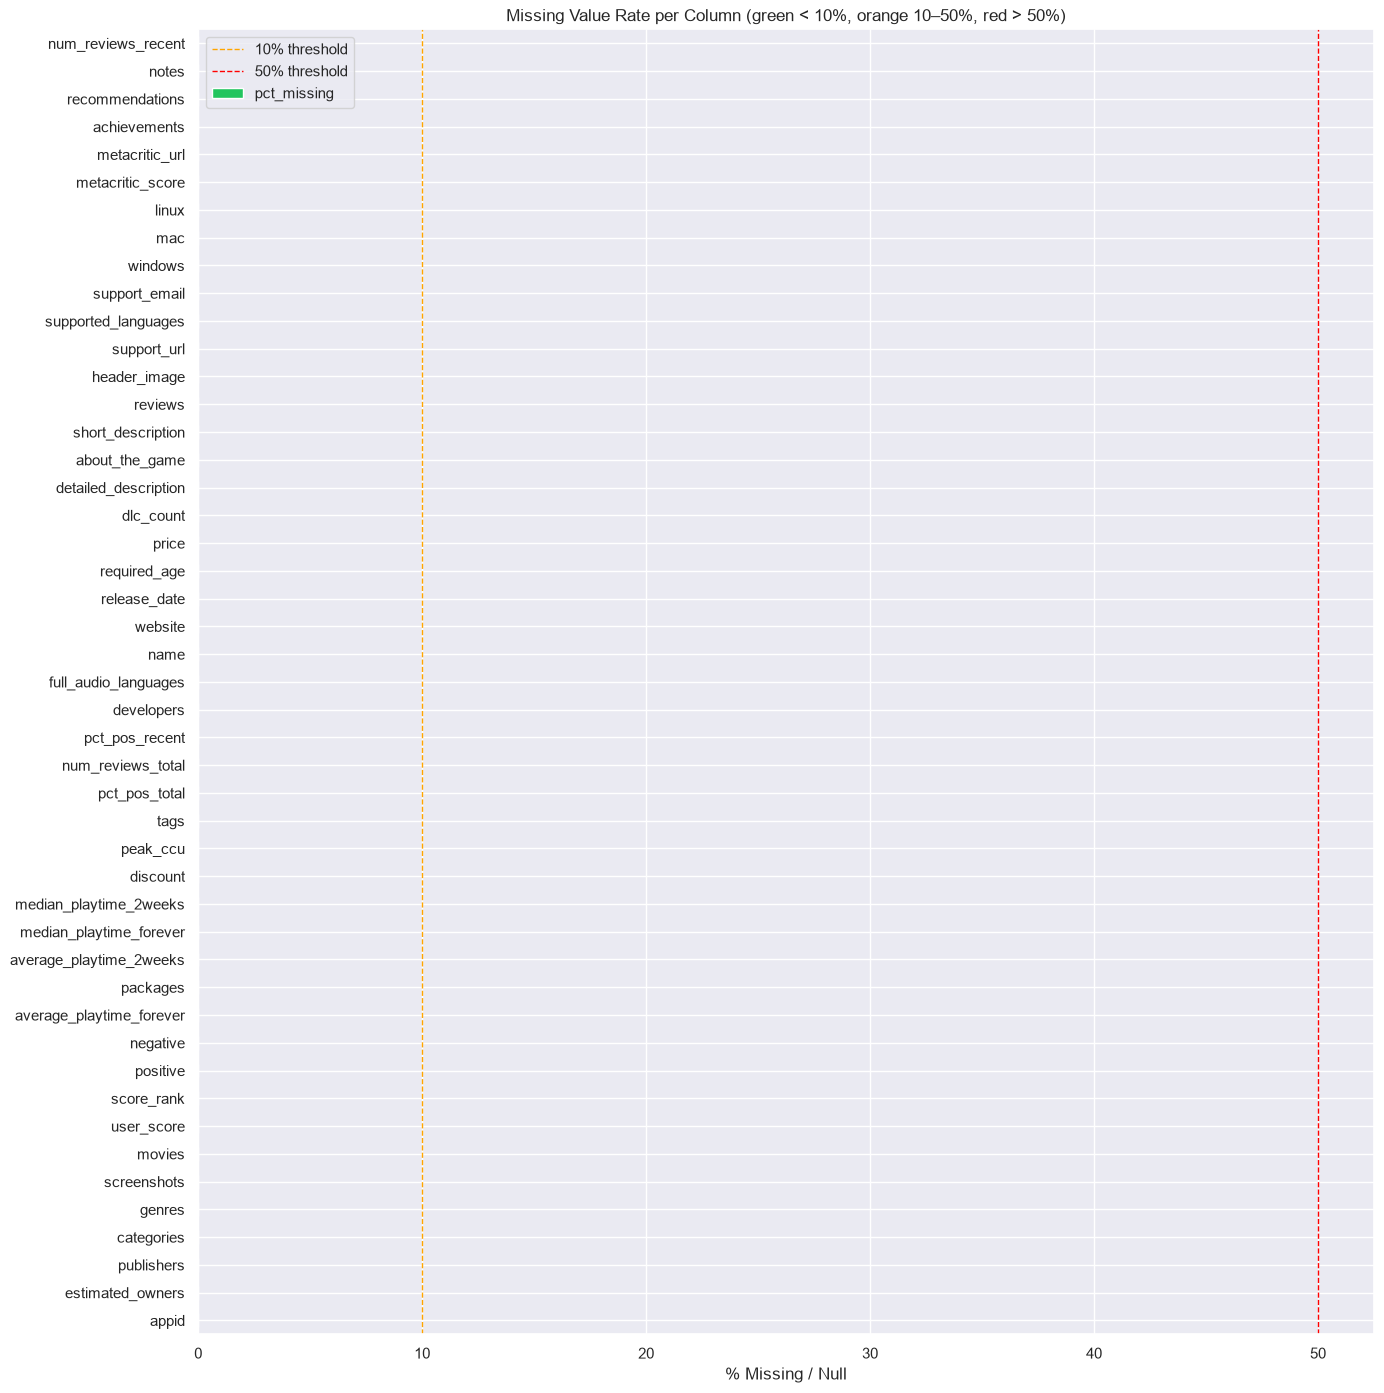

Saved: 01_missing_values.png


In [10]:
fig, ax = plt.subplots(figsize=(14, max(5, len(audit) * 0.3))) # Adjust height of the plot based on number of columns

colors = ['#ef4444' if v > 50 else '#f59e0b' if v > 10 else '#22c55e'
          for v in audit['pct_missing']] # Define colors based on missing rate
audit['pct_missing'].plot(kind='barh', ax=ax, color=colors) # Plot the bar chart with defined colors
ax.axvline(10, color='orange', linestyle='--', linewidth=1, label='10% threshold') # Add vertical lines at 10% and 50% missing rate thresholds
ax.axvline(50, color='red',    linestyle='--', linewidth=1, label='50% threshold') # Add vertical lines at 10% and 50% missing rate thresholds

ax.set_xlabel('% Missing / Null') # Set x-axis label
ax.set_title('Missing Value Rate per Column (green < 10%, orange 10–50%, red > 50%)') # Set title of the plot
ax.legend()  # Add legend to the plot    
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.savefig(FIGURES_DIR / '01_missing_values.png', dpi=150, bbox_inches='tight') # Save the plot to a file

plt.show() # Display the plot
print('Saved: 01_missing_values.png')


## 5. Column Decision Matrix — Keep / Drop / Fill

Each column is assessed against three criteria:
1. **Pre-launch validity** — is this information available before a game releases?
2. **Missing rate** — is there enough coverage to be useful?
3. **Relevance** — does it plausibly relate to reception quality?

Decisions recorded here feed directly into `src/config.py`.


In [11]:
# ── COLUMN MAPPING ────────────────────────────────────────────────────────────
# Different dataset versions use different column names.
# find_col() tries a list of candidate names and returns whichever exists in the CSV.
def find_col(candidates, columns):
    """Case-insensitive search — returns the actual CSV column name or None."""
    cols_lower = {c.lower(): c for c in columns}
    for c in candidates:
        if c.lower() in cols_lower:
            return cols_lower[c.lower()]
    return None

all_cols = df_raw.columns.tolist()

col_map = {
    # ── Identity (kept for debugging only — not features) ──────────────────
    'app_id':   find_col(['appid', 'app_id', 'steam_appid'], all_cols),
    'name':     find_col(['name', 'game_name', 'title'], all_cols),
    'release_date': find_col(['release_date', 'releasedate'], all_cols),

    # ── Label source: pct_pos_total is the % (0–100), NOT 'positive' which is raw count ──
    'positive': find_col(['pct_pos_total', 'positive_ratio', 'positive_reviews_pct'], all_cols),

    # ── Filter column: uses -1 sentinel; never used as a model feature ──────
    'user_reviews': find_col(['num_reviews_total', 'user_reviews', 'total_reviews'], all_cols),

    # ── Tier 1 raw features ────────────────────────────────────────────────
    'price':        find_col(['price', 'price_usd', 'initial_price'], all_cols),
    'required_age': find_col(['required_age', 'age_rating', 'min_age'], all_cols),
    'genres':       find_col(['genres', 'genre'], all_cols),

    # ── Tier 2 raw features ────────────────────────────────────────────────
    # dlc_count is NOT used as standalone — only feeds price_to_dlc_ratio derived feature
    'dlc_count':    find_col(['dlc_count', 'dlcs', 'num_dlc'], all_cols),
    # is_free does NOT exist in this CSV — derived from price == 0 in Section 6
    'is_free':      find_col(['is_free', 'free_to_play'], all_cols),

    # ── Tier 3 raw features ────────────────────────────────────────────────
    'tags':         find_col(['tags', 'steam_tags', 'popular_tags'], all_cols),
    'categories':   find_col(['categories', 'category'], all_cols),
    # windows is DROPPED — 100% of games support it (zero variance)
    # mac and linux feed platform_coverage = (mac + linux) / 2
    'windows':      find_col(['windows', 'pc', 'win'], all_cols),
    'mac':          find_col(['mac', 'macos'], all_cols),
    'linux':        find_col(['linux'], all_cols),
    # Parsed to integer counts for use as features
    'supported_languages':  find_col(['supported_languages', 'languages'], all_cols),
    'full_audio_languages': find_col(['full_audio_languages'], all_cols),
    # achievements: direct integer — development effort signal
    'achievements': find_col(['achievements'], all_cols),
    # screenshot_count and movie_count derived by parsing list lengths
    'screenshots':  find_col(['screenshots'], all_cols),
    'movies':       find_col(['movies'], all_cols),
    # has_website derived as binary flag from this column
    'website':      find_col(['website'], all_cols),

    # ── Tier 5 (NLP source) ────────────────────────────────────────────────
    'short_description': find_col(['short_description', 'description', 'desc'], all_cols),

    # ── Dropped — kept in map for decision tracking ────────────────────────
    'developers': find_col(['developers', 'developer'], all_cols),
    'publishers': find_col(['publishers', 'publisher'], all_cols),
}

print('=== COLUMN MAPPING (expected → actual CSV name) ===')
for k, v in col_map.items():
    status = '✓' if v else '✗ NOT FOUND — will be derived or skipped'
    print(f'  {k:<25} → {str(v):<35} {status}')

print(f'\nUnmapped columns (will be formally DROPPED in decision matrix):')
mapped = set(v for v in col_map.values() if v)
unmapped = [c for c in all_cols if c not in mapped]
print(unmapped)


=== COLUMN MAPPING (expected → actual CSV name) ===
  app_id                    → appid                               ✓
  name                      → name                                ✓
  release_date              → release_date                        ✓
  positive                  → pct_pos_total                       ✓
  user_reviews              → num_reviews_total                   ✓
  price                     → price                               ✓
  required_age              → required_age                        ✓
  genres                    → genres                              ✓
  dlc_count                 → dlc_count                           ✓
  is_free                   → None                                ✗ NOT FOUND — will be derived or skipped
  tags                      → tags                                ✓
  categories                → categories                          ✓
  windows                   → windows                             ✓
  mac                    

In [12]:
# ── COMPLETE COLUMN DECISION MATRIX ───────────────────────────────────────────
# Every column in the dataset is assigned one of four decisions:
#   KEEP — Tx    → model feature in that tier
#   LABEL SOURCE → prediction target (y), never a feature (X)
#   FILTER ONLY  → used to clean data only, never a feature
#   DROP         → excluded entirely

def d(decision, reason):
    return {'decision': decision, 'reason': reason}

DECISIONS = {

    # ── LABEL SOURCE ──────────────────────────────────────────────────────
    # pct_pos_total is what we predict. Converting to binary in Section 6.
    # NEVER used as a feature — doing so would be data leakage.
    'pct_pos_total':    d('LABEL SOURCE', 'Converted to binary reception_label (≥75%=1). Never a feature.'),

    # ── FILTER ONLY ──────────────────────────────────────────────────────
    # num_reviews_total is post-launch but only used as a data quality gate.
    # Games with <100 reviews have unreliable positive ratios. Never a feature.
    'num_reviews_total': d('FILTER ONLY', 'Used to filter ≥100 reviews only. Post-launch — never a feature.'),

    # ── TIER 1 — Core (price, age, genres, genre_concentration derived) ──
    'price':         d('KEEP — T1', 'Pre-launch. Core monetisation signal. Known at store page creation.'),
    'required_age':  d('KEEP — T1', 'Pre-launch. Age rating set by developer at submission.'),
    'genres':        d('KEEP — T1', 'Pre-launch. Top 10 genres → one-hot. Also feeds genre_concentration.'),

    # ── TIER 2 — Monetisation (is_free derived, price_to_dlc_ratio derived) ──
    # dlc_count is NOT used as standalone — r=0.005, p=0.477 (not significant)
    # It only feeds price_to_dlc_ratio derived feature.
    'dlc_count':     d('KEEP — T2 (derived only)', 'Not used raw (r=0.005, insignificant). Only feeds price_to_dlc_ratio.'),
    # is_free is derived in Section 6 (price == 0) — no column exists
    'is_free':       d('KEEP — T2 (derived)', 'Derived from price==0. Free games have lower reception rate (65.5% vs 73.4%).'),

    # ── TIER 3 — Content ─────────────────────────────────────────────────
    'tags':          d('KEEP — T3', 'Borderline pre-launch. Top 20 tags → one-hot. Documented as limitation.'),
    'categories':    d('KEEP — T3', 'Pre-launch. Developer-declared features → one-hot (multiplayer, controller etc.).'),
    # windows DROPPED — 100% of 20,383 games support Windows (zero variance, useless)
    'windows':       d('DROP', 'Zero variance — 100% of games support Windows. Teaches model nothing.'),
    # mac and linux feed platform_coverage = (mac + linux) / 2
    # mac r=0.097, linux r=0.094 — strongest individual signals in dataset
    'mac':           d('KEEP — T3 (derived)', 'Feeds platform_coverage=(mac+linux)/2. r=0.097 — strongest positive signal.'),
    'linux':         d('KEEP — T3 (derived)', 'Feeds platform_coverage=(mac+linux)/2. r=0.094 — second strongest signal.'),
    'supported_languages':  d('KEEP — T3 (derived)', 'Parsed to supported_languages_count integer. r=0.015 (weak but significant).'),
    'achievements': d('KEEP — T3 (derived)', 'Binary: has_achievements=(achievements>0). 0 achiev=64.7% vs >0=74.4% well-received.'),
    'full_audio_languages': d('DROP', 'r=0.0076, p=0.277 — not statistically significant. No usable signal.'),
    'screenshots':   d('KEEP — T3 (derived)', 'Parsed to screenshot_count. Marketing effort signal. Pre-launch.'),
    'movies':        d('KEEP — T3 (derived)', 'Parsed to movie_count. Trailer production = investment signal. Pre-launch.'),
    'website':       d('KEEP — T3 (derived)', 'Derived to has_website binary. Studio professionalism proxy.'),

    # ── TIER 5 — NLP source ───────────────────────────────────────────────
    'short_description': d('KEEP — T5', 'Developer-written pre-launch text. SBERT encoding source for Model E.'),

    # ── DROP — Identity / metadata ────────────────────────────────────────
    'appid':         d('DROP', 'Unique identifier. No predictive value.'),
    'name':          d('DROP', 'Game title. Not a structured feature.'),
    'release_date':  d('DROP', 'Post-concept metadata. Not used in any tier.'),
    'developers':    d('DROP', 'Too high cardinality. Model cannot generalise to unseen studios.'),
    'publishers':    d('DROP', 'Same cardinality problem as developers.'),

    # ── DROP — Redundant text ─────────────────────────────────────────────
    'detailed_description': d('DROP', 'Redundant with short_description — same content, much longer.'),
    'about_the_game':       d('DROP', 'Redundant with short_description.'),

    # ── DROP — Metadata / URLs (not structured features) ─────────────────
    'reviews':       d('DROP', 'Press quotes — 88% missing, post-publication.'),
    'header_image':  d('DROP', 'Store image URL — not a structured feature.'),
    'support_url':   d('DROP', 'Support link — no predictive signal.'),
    'support_email': d('DROP', 'Support contact — no predictive signal.'),
    'notes':         d('DROP', 'Content warnings — 81% missing, too sparse.'),
    'packages':      d('DROP', 'Complex nested purchase structure — too noisy, no clear signal.'),

    # ── DROP — Post-launch review / score data (leakage) ─────────────────
    'positive':          d('DROP', 'Raw count of positive reviews — post-launch. pct_pos_total used instead.'),
    'negative':          d('DROP', 'Raw count of negative reviews — post-launch.'),
    'metacritic_score':  d('DROP', 'Post-launch review score — direct leakage.'),
    'metacritic_url':    d('DROP', 'Post-launch URL — not a feature.'),
    'recommendations':   d('DROP', 'Post-launch Steam recommendation count.'),
    'user_score':        d('DROP', 'Virtually all values are 0 — no usable variance.'),
    'score_rank':        d('DROP', '99.96% null — also post-launch.'),
    'pct_pos_recent':    d('DROP', 'Recent review percentage — post-launch.'),
    'num_reviews_recent':d('DROP', 'Recent review count — post-launch.'),

    # ── DROP — Post-launch usage / popularity data (leakage) ─────────────
    'estimated_owners':       d('DROP', 'Ownership range — post-launch, stored as string range.'),
    'average_playtime_forever': d('DROP', 'Post-launch playtime data.'),
    'average_playtime_2weeks':  d('DROP', 'Post-launch playtime data.'),
    'median_playtime_forever':  d('DROP', 'Post-launch playtime data.'),
    'median_playtime_2weeks':   d('DROP', 'Post-launch playtime data.'),
    'peak_ccu':           d('DROP', 'Peak concurrent users — post-launch.'),
    'discount':           d('DROP', 'Current store discount — volatile, post-launch pricing.'),
}

# Verify every column in the CSV has a decision
all_decided = set(DECISIONS.keys())
missing_decisions = [c for c in all_cols if c not in all_decided]
print(f'Columns with a decision : {len(DECISIONS)}')
print(f'Columns in CSV          : {len(all_cols)}')
print(f'Columns WITHOUT decision: {len(missing_decisions)}')
if missing_decisions:
    print('  → These still need a decision:', missing_decisions)
else:
    print('  → All columns accounted for ✓')

print()
decision_df = pd.DataFrame(DECISIONS).T.reset_index()
decision_df.columns = ['column', 'decision', 'reason']
decision_df = decision_df.sort_values('decision')
print('=== COLUMN DECISION MATRIX ===')
decision_df


Columns with a decision : 48
Columns in CSV          : 47
Columns WITHOUT decision: 0
  → All columns accounted for ✓

=== COLUMN DECISION MATRIX ===


,column,decision,reason
9,windows,DROP,Zero variance — 100% of games support Windows. Teaches model nothing.
14,full_audio_languages,DROP,"r=0.0076, p=0.277 — not statistically significant. No usable signal."
19,appid,DROP,Unique identifier. No predictive value.
20,name,DROP,Game title. Not a structured feature.
21,release_date,DROP,Post-concept metadata. Not used in any tier.
22,developers,DROP,Too high cardinality. Model cannot generalise to unseen studios.
23,publishers,DROP,Same cardinality problem as developers.
24,detailed_description,DROP,"Redundant with short_description — same content, much longer."
25,about_the_game,DROP,Redundant with short_description.
26,reviews,DROP,"Press quotes — 88% missing, post-publication."


In [13]:
# ── DECISION SUMMARY ──────────────────────────────────────────────────────────
# Count how many columns fall into each decision category.
# This gives a quick sanity check before moving to modelling.

from collections import defaultdict
decision_counts = defaultdict(list)
for col, info in DECISIONS.items():
    dec = info['decision'].split(' —')[0].split(' (')[0].strip()  # Normalise label
    decision_counts[dec].append(col)

print('=== DECISION SUMMARY ===')
for dec, cols in sorted(decision_counts.items()):
    print(f'\n  {dec} ({len(cols)} columns):')
    for c in cols:
        print(f'    - {c}')


=== DECISION SUMMARY ===

  DROP (31 columns):
    - windows
    - full_audio_languages
    - appid
    - name
    - release_date
    - developers
    - publishers
    - detailed_description
    - about_the_game
    - reviews
    - header_image
    - support_url
    - support_email
    - notes
    - packages
    - positive
    - negative
    - metacritic_score
    - metacritic_url
    - recommendations
    - user_score
    - score_rank
    - pct_pos_recent
    - num_reviews_recent
    - estimated_owners
    - average_playtime_forever
    - average_playtime_2weeks
    - median_playtime_forever
    - median_playtime_2weeks
    - peak_ccu
    - discount

  FILTER ONLY (1 columns):
    - num_reviews_total

  KEEP (15 columns):
    - price
    - required_age
    - genres
    - dlc_count
    - is_free
    - tags
    - categories
    - mac
    - linux
    - supported_languages
    - achievements
    - screenshots
    - movies
    - website
    - short_description

  LABEL SOURCE (1 columns):


## 6. Apply the 100-Review Filter & Create the Label

This is the exact filter used in the proposal. Done here for exploratory purposes —  
the definitive version lives in `02_base_model_evaluation.ipynb` and `src/data/loader.py`.

**Label rule:** `reception_label = 1` if `positive ≥ 0.75`, else `0`  
This aligns with Steam's *Mostly Positive* boundary (Valve Corporation, 2025).


In [14]:
COL_REVIEWS  = col_map.get('user_reviews') or 'num_reviews_total' 
COL_POSITIVE = col_map.get('positive')     or 'pct_pos_total'

print(f'Review count column : {COL_REVIEWS}')
print(f'Positive pct column : {COL_POSITIVE}')
print()

# Convert columns to numeric, forcing errors to NaNs
df_raw[COL_REVIEWS]  = pd.to_numeric(df_raw[COL_REVIEWS],  errors='coerce')
df_raw[COL_POSITIVE] = pd.to_numeric(df_raw[COL_POSITIVE], errors='coerce')

# Remove sentinel -1 values (no review data)
df_valid = df_raw[df_raw[COL_REVIEWS] > 0].copy()
print(f'After removing -1 sentinel rows : {len(df_valid):,} games')

# Apply ≥100 review filter
df = df_valid[df_valid[COL_REVIEWS] >= 100].copy()
print(f'After ≥100 review filter        : {len(df):,} games  ({len(df)/len(df_raw)*100:.1f}% of raw)')

# pct_pos_total is already 0–100 — normalise to 0.0–1.0 ratio
pos_max = df[COL_POSITIVE].max()
pos_min = df[COL_POSITIVE].min()
print(f'\npct_pos_total range in filtered data: {pos_min} to {pos_max}')

if pos_max > 1.0:
    print('Confirmed: column is 0–100 integer → dividing by 100')
    df['positive_ratio'] = df[COL_POSITIVE] / 100.0
else:
    print('Column already 0–1 float')
    df['positive_ratio'] = df[COL_POSITIVE]

# Create binary label at 75% threshold
df['reception_label'] = (df['positive_ratio'] >= 0.75).astype(int)

# Derive is_free from price (since is_free column doesn't exist)
COL_PRICE = col_map.get('price') or 'price'
df['is_free'] = (df[COL_PRICE] == 0.0).astype(int)
# Update col_map so downstream cells know the derived column name
col_map['is_free'] = 'is_free'

# Print out class distribution after filtering and thresholding
counts = df['reception_label'].value_counts()
print(f'\nClass distribution after filter:')
print(f'  Well Received   (label=1): {counts.get(1,0):>6,}  ({counts.get(1,0)/len(df)*100:.1f}%)')
print(f'  Not Well Received (label=0): {counts.get(0,0):>6,}  ({counts.get(0,0)/len(df)*100:.1f}%)')
print(f'\nis_free derived from price==0: {df["is_free"].sum():,} free games ({df["is_free"].mean()*100:.1f}%)')

Review count column : num_reviews_total
Positive pct column : pct_pos_total

After removing -1 sentinel rows : 53,199 games
After ≥100 review filter        : 20,383 games  (22.7% of raw)

pct_pos_total range in filtered data: 7 to 100
Confirmed: column is 0–100 integer → dividing by 100

Class distribution after filter:
  Well Received   (label=1): 14,631  (71.8%)
  Not Well Received (label=0):  5,752  (28.2%)

is_free derived from price==0: 4,268 free games (20.9%)


## 7. Numerical Feature Distributions

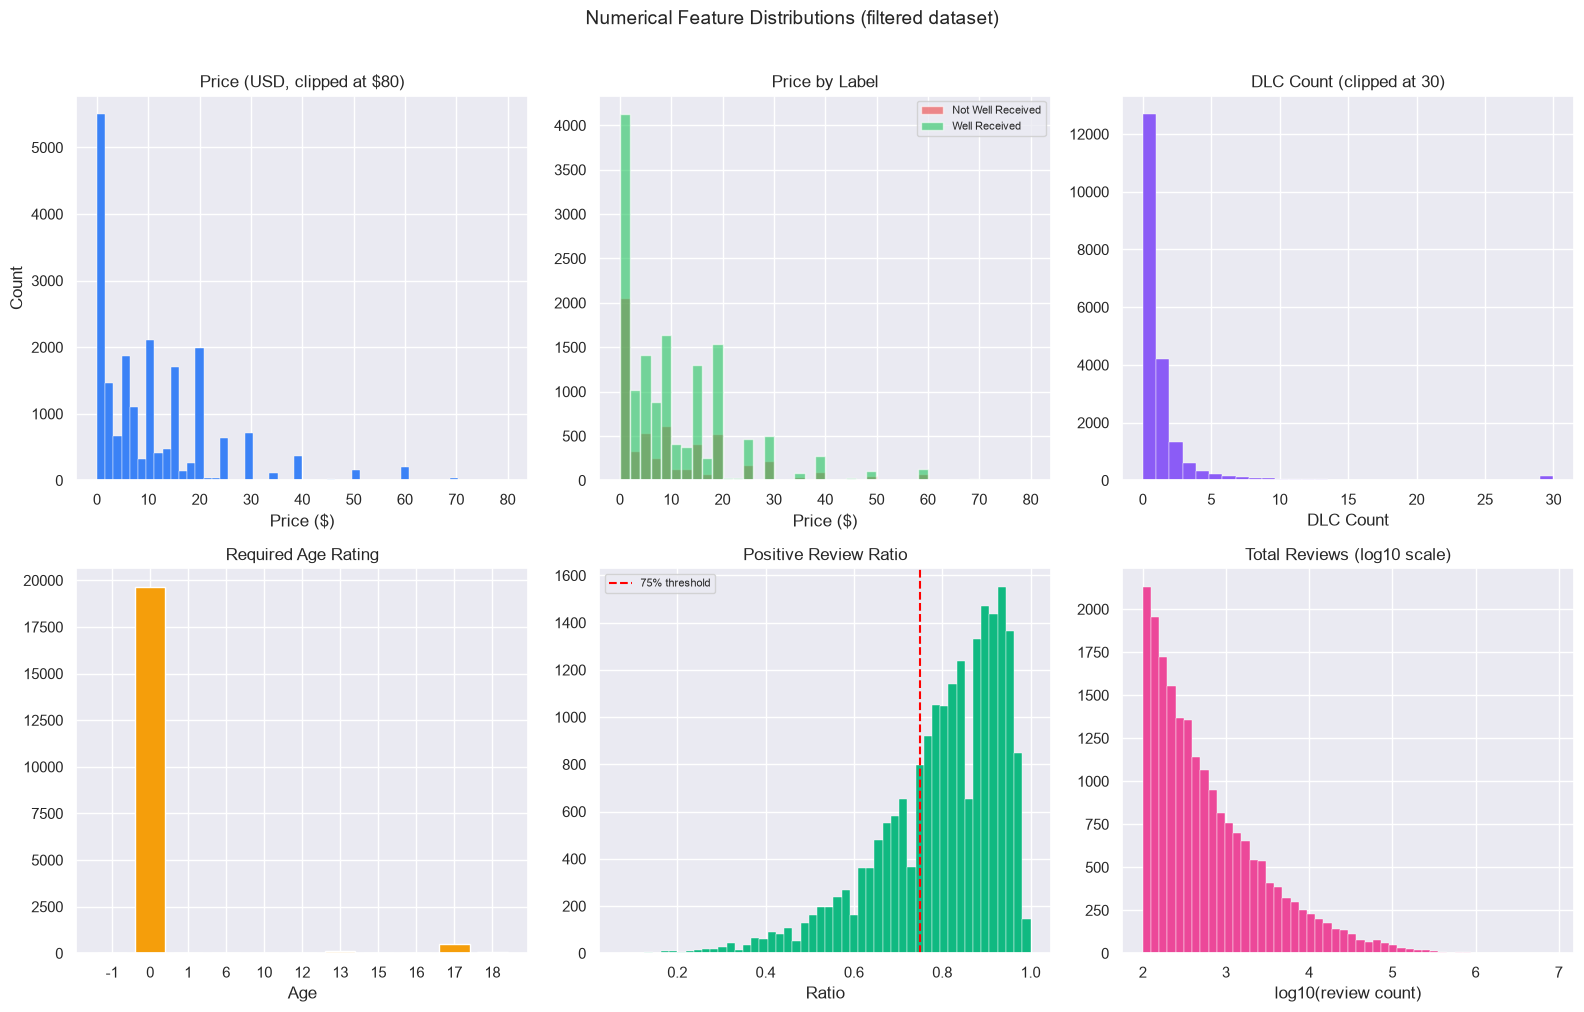

Saved: 01_numerical_distributions.png


In [15]:
COL_PRICE   = col_map.get('price')        or 'price'
COL_DLC     = col_map.get('dlc_count')    or 'dlc_count'
COL_AGE     = col_map.get('required_age') or 'required_age'
COL_IS_FREE = col_map.get('is_free')      or 'is_free'

# Convert to numeric, coercing errors to NaN
for col in [COL_PRICE, COL_DLC, COL_AGE]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Plot distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Numerical Feature Distributions (filtered dataset)', fontsize=14, y=1.01)

# Price (clip extreme outliers for visibility)
price_data = df[COL_PRICE].clip(0, 80)
axes[0, 0].hist(price_data.dropna(), bins=50, color='#3b82f6', edgecolor='white', linewidth=0.3)
axes[0, 0].set_title('Price (USD, clipped at $80)')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Count')

# Price by label
for label, colour in [(0, '#ef4444'), (1, '#22c55e')]:
    subset = df[df['reception_label'] == label][COL_PRICE].clip(0, 80)
    axes[0, 1].hist(subset.dropna(), bins=40, alpha=0.6, color=colour,
                    label='Well Received' if label == 1 else 'Not Well Received')
axes[0, 1].set_title('Price by Label')
axes[0, 1].set_xlabel('Price ($)')
axes[0, 1].legend(fontsize=8)

# DLC count
dlc_data = df[COL_DLC].clip(0, 30)
axes[0, 2].hist(dlc_data.dropna(), bins=31, color='#8b5cf6', edgecolor='white', linewidth=0.3)
axes[0, 2].set_title('DLC Count (clipped at 30)')
axes[0, 2].set_xlabel('DLC Count')

# Required age
age_counts = df[COL_AGE].value_counts().sort_index()
axes[1, 0].bar(age_counts.index.astype(str), age_counts.values, color='#f59e0b')
axes[1, 0].set_title('Required Age Rating')
axes[1, 0].set_xlabel('Age')

# Positive review ratio distribution
axes[1, 1].hist(df['positive_ratio'].dropna(), bins=50, color='#10b981', edgecolor='white', linewidth=0.3)
axes[1, 1].axvline(0.75, color='red', linestyle='--', linewidth=1.5, label='75% threshold')
axes[1, 1].set_title('Positive Review Ratio')
axes[1, 1].set_xlabel('Ratio')
axes[1, 1].legend(fontsize=8)

# Total reviews (log scale)
axes[1, 2].hist(np.log10(df[COL_REVIEWS].clip(1)), bins=50, color='#ec4899', edgecolor='white', linewidth=0.3)
axes[1, 2].set_title('Total Reviews (log10 scale)')
axes[1, 2].set_xlabel('log10(review count)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_numerical_distributions.png')

In [16]:
# Summary statistics for numerical columns by label 
for col in [COL_PRICE, COL_DLC, COL_AGE]:
    print(f'\n--- {col} ---')
    print(df.groupby('reception_label')[col].describe().T.round(3))


--- price ---
reception_label         0          1
count           5752.0000 14631.0000
mean              10.2350    10.7670
std               12.3410    11.3310
min                0.0000     0.0000
25%                0.0000     1.9400
50%                5.9900     7.9900
75%               14.9900    14.9900
max               89.9900    79.9900

--- dlc_count ---
reception_label         0          1
count           5752.0000 14631.0000
mean               1.5950     1.9330
std               14.2820    35.0130
min                0.0000     0.0000
25%                0.0000     0.0000
50%                0.0000     0.0000
75%                1.0000     1.0000
max              765.0000  3427.0000

--- required_age ---
reception_label         0          1
count           5752.0000 14631.0000
mean               0.7040     0.5310
std                3.3370     2.9120
min                0.0000    -1.0000
25%                0.0000     0.0000
50%                0.0000     0.0000
75%                

In [17]:
# Null check on numerical columns 
num_cols = [COL_PRICE, COL_DLC, COL_AGE, COL_IS_FREE]
for col in num_cols:
    if col in df.columns:
        n_null = df[col].isna().sum()
        pct = n_null / len(df) * 100
        print(f'{col:<30} null: {n_null:>5}  ({pct:.2f}%)')
        if n_null > 0:
            print(f'  → Fill strategy: 0 for DLC/is_free, median for price/age')

price                          null:     0  (0.00%)
dlc_count                      null:     0  (0.00%)
required_age                   null:     0  (0.00%)
is_free                        null:     0  (0.00%)


## 8. Genre Analysis

Genres are stored as string-encoded Python lists, e.g. `"['Action', 'RPG']"`.  
We parse them, count frequency, and identify the **top 10** for one-hot encoding.

> **Pre-launch validity:** Genres are set by the developer at submission — fully pre-launch.


In [18]:
COL_GENRES = col_map.get('genres') or 'genres'

def parse_list_col(series):
    """Parse a column of string-encoded lists. Handles ast.literal_eval, JSON, and plain strings."""
    parsed = []
    for val in series:
        if pd.isna(val) or str(val).strip() in ('', '[]', '{}'):
            parsed.append([])
            continue
        try:
            result = ast.literal_eval(str(val))
            if isinstance(result, list):
                parsed.append([str(x).strip() for x in result])
            elif isinstance(result, str):
                parsed.append([result.strip()])
            else:
                parsed.append([])
        except Exception:
            # Fall back: split by comma
            items = [x.strip().strip("'\"") for x in str(val).split(',') if x.strip()]
            parsed.append(items)
    return parsed

df['genres_parsed'] = parse_list_col(df[COL_GENRES])
all_genres = [g for sublist in df['genres_parsed'] for g in sublist if g]
genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.most_common(30), columns=['genre', 'count'])

print(f'Total unique genres in filtered dataset: {len(genre_counts)}')
print(f'Games with at least one genre assigned: {(df["genres_parsed"].apply(len) > 0).sum():,}')
print(f'Games with NO genre assigned: {(df["genres_parsed"].apply(len) == 0).sum():,}')
print()
print('Top 30 genres:')
genre_df

Total unique genres in filtered dataset: 27
Games with at least one genre assigned: 20,290
Games with NO genre assigned: 93

Top 30 genres:


,genre,count
0,Indie,13600
1,Adventure,8896
2,Action,8392
3,Casual,6771
4,Simulation,5340
5,RPG,5076
6,Strategy,4515
7,Free To Play,3127
8,Early Access,1653
9,Massively Multiplayer,898


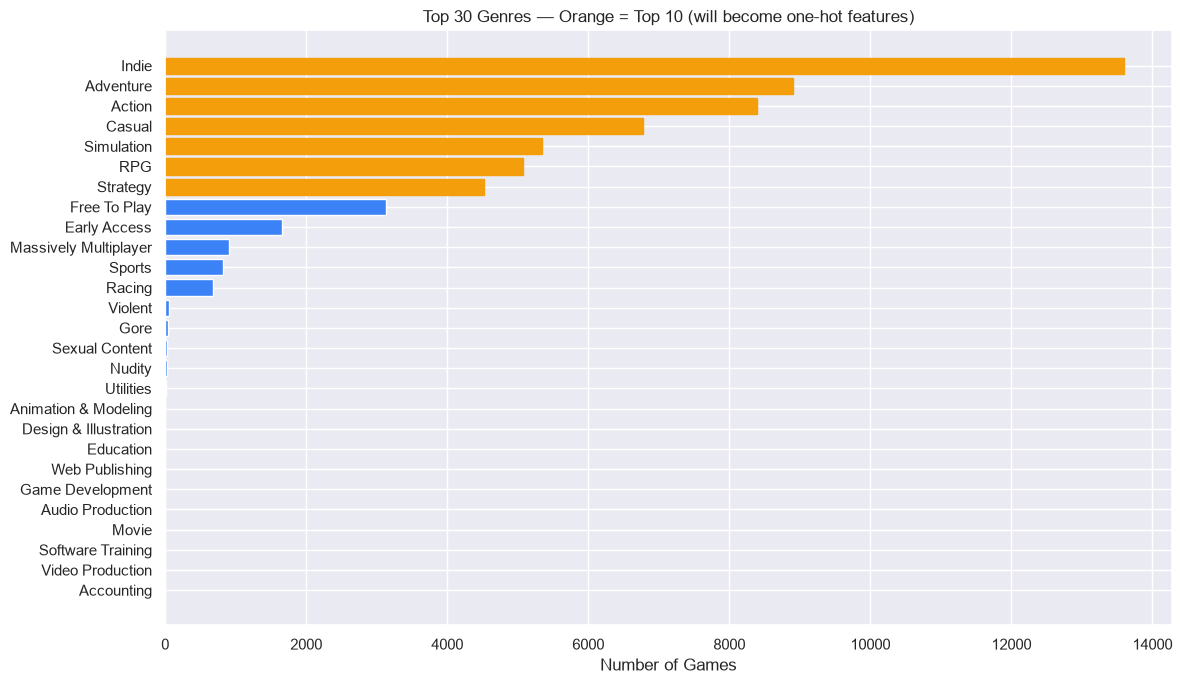

Saved: 01_genre_frequency.png


In [19]:
# ── Genre frequency bar chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
top30 = genre_df.head(30)
bars = ax.barh(top30['genre'][::-1], top30['count'][::-1], color='#3b82f6')
# Highlight top 10 (these become one-hot features)
for i, bar in enumerate(bars):
    if i >= 20:  # last 10 in reversed list = top 10
        bar.set_color('#f59e0b')
ax.set_xlabel('Number of Games')
ax.set_title('Top 30 Genres — Orange = Top 10 (will become one-hot features)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_genre_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_genre_frequency.png')

In [20]:
# ── Genre count per game distribution ─────────────────────────────────────
df['genre_count'] = df['genres_parsed'].apply(len)
print('Genres per game:')
print(df['genre_count'].describe())
print()
print('Distribution:')
print(df['genre_count'].value_counts().sort_index())

# Top 10 genres to become features
TOP_10_GENRES = [g for g, _ in genre_counts.most_common(10)]
print(f'\n=== TOP 10 GENRES (for one-hot encoding in config.py) ===')
for i, g in enumerate(TOP_10_GENRES, 1):
    print(f'  {i:>2}. {g}  (n={genre_counts[g]:,})')

Genres per game:
count   20383.0000
mean        2.9402
std         1.3782
min         0.0000
25%         2.0000
50%         3.0000
75%         4.0000
max        11.0000
Name: genre_count, dtype: float64

Distribution:
genre_count
0       93
1     2705
2     5491
3     6029
4     3505
5     1650
6      612
7      207
8       62
9       21
10       7
11       1
Name: count, dtype: int64

=== TOP 10 GENRES (for one-hot encoding in config.py) ===
   1. Indie  (n=13,600)
   2. Adventure  (n=8,896)
   3. Action  (n=8,392)
   4. Casual  (n=6,771)
   5. Simulation  (n=5,340)
   6. RPG  (n=5,076)
   7. Strategy  (n=4,515)
   8. Free To Play  (n=3,127)
   9. Early Access  (n=1,653)
  10. Massively Multiplayer  (n=898)


In [21]:
# ── Genre → label correlation (reception rate per genre) ──────────────────
genre_label_rates = {}
for genre in TOP_10_GENRES:
    has_genre = df['genres_parsed'].apply(lambda lst: genre in lst)
    rate = df.loc[has_genre, 'reception_label'].mean()
    count = has_genre.sum()
    genre_label_rates[genre] = {'count': count, 'well_received_rate': round(rate, 4)}

genre_rate_df = pd.DataFrame(genre_label_rates).T.sort_values('well_received_rate', ascending=False)
print('Well-Received rate by genre (top 10):')
print(genre_rate_df)

Well-Received rate by genre (top 10):
                           count  well_received_rate
Casual                 6771.0000              0.7585
Indie                 13600.0000              0.7477
Adventure              8896.0000              0.7340
Action                 8392.0000              0.6857
RPG                    5076.0000              0.6712
Simulation             5340.0000              0.6592
Strategy               4515.0000              0.6523
Free To Play           3127.0000              0.6431
Early Access           1653.0000              0.6189
Massively Multiplayer   898.0000              0.3619


## 9. Tag Analysis

> **Pre-launch validity note:** Steam tags are applied by users after launch, making them  
> technically post-launch signals. However, genre-type tags (e.g. 'Singleplayer', 'RPG')  
> are commonly known before release and are retained as a documented limitation.  
> Post-launch behavioural tags (e.g. 'Masterpiece', 'Hidden Gem') must be excluded.


In [22]:
COL_TAGS = col_map.get('tags') or 'tags'

def parse_tags_col(series):
    """
    Tags are stored as dicts: {'FPS': 90857, 'Shooter': 65397, ...}
    We extract just the tag names (keys), ignoring vote counts.
    """
    parsed = []
    for val in series:
        if pd.isna(val) or str(val).strip() in ('', '[]', '{}'):
            parsed.append([])
            continue
        try:
            result = ast.literal_eval(str(val))
            if isinstance(result, dict):
                parsed.append(list(result.keys()))
            elif isinstance(result, list):
                parsed.append([str(x).strip() for x in result])
            else:
                parsed.append([])
        except Exception:
            parsed.append([])
    return parsed

df['tags_parsed'] = parse_tags_col(df[COL_TAGS])
all_tags = [t for sublist in df['tags_parsed'] for t in sublist if t]
tag_counts = Counter(all_tags)
tag_df = pd.DataFrame(tag_counts.most_common(40), columns=['tag', 'count'])

print(f'Total unique tags: {len(tag_counts)}')
print(f'Games with at least one tag: {(df["tags_parsed"].apply(len) > 0).sum():,}')
print(f'Games with NO tag: {(df["tags_parsed"].apply(len) == 0).sum():,}')
print()
print('Top 40 tags:')
tag_df

Total unique tags: 452
Games with at least one tag: 17,744
Games with NO tag: 2,639

Top 40 tags:


,tag,count
0,Singleplayer,11869
1,Indie,10091
2,Adventure,8598
3,Action,8158
4,Casual,6327
5,2D,5302
6,Simulation,4891
7,RPG,4733
8,Atmospheric,4651
9,Story Rich,4507


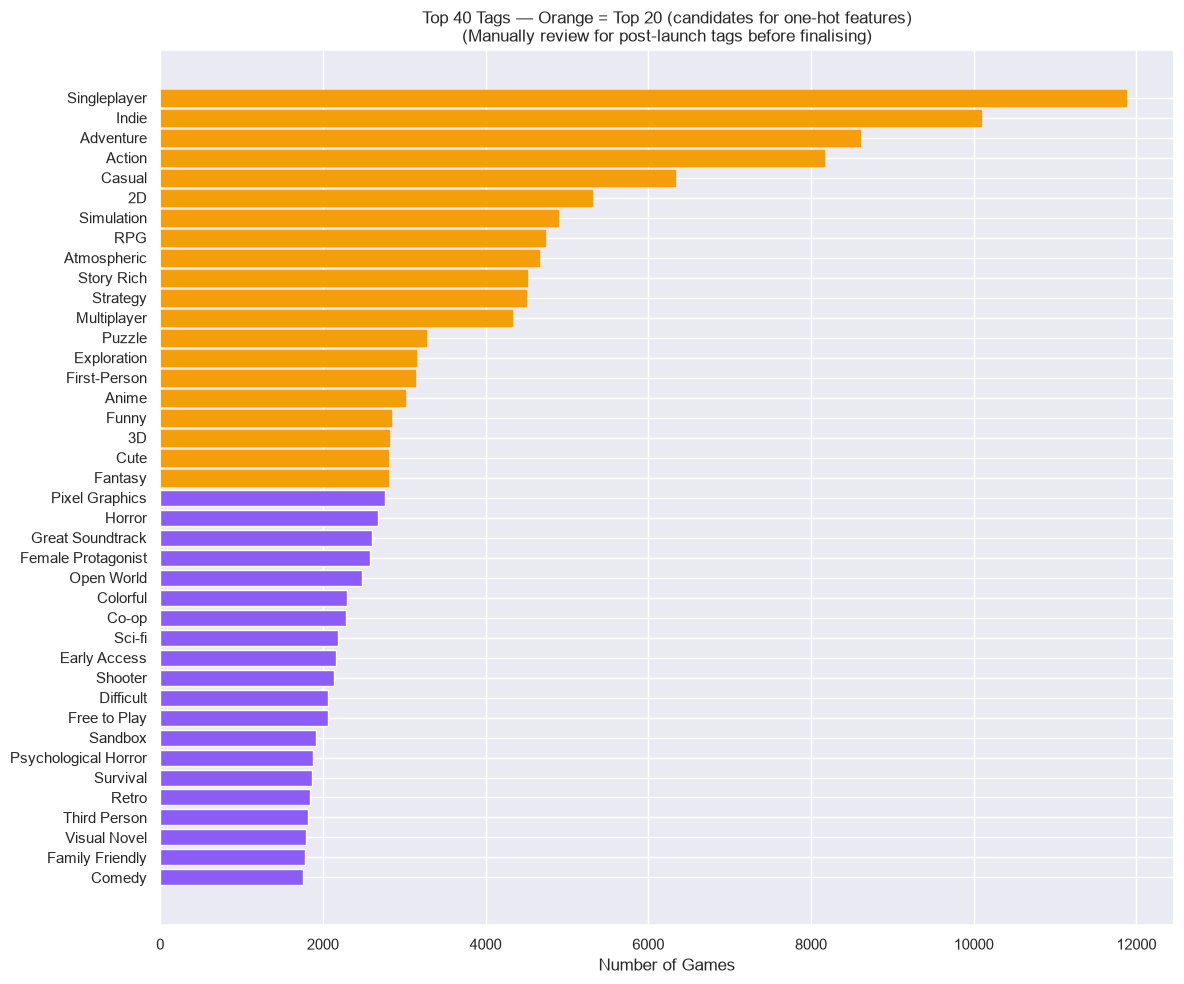

Saved: 01_tag_frequency.png


In [23]:
fig, ax = plt.subplots(figsize=(12, 10))
top40 = tag_df.head(40)
bars = ax.barh(top40['tag'][::-1], top40['count'][::-1], color='#8b5cf6')
for i, bar in enumerate(bars):
    if i >= 20:  # top 20 tags
        bar.set_color('#f59e0b')
ax.set_xlabel('Number of Games')
ax.set_title('Top 40 Tags — Orange = Top 20 (candidates for one-hot features)\n'
             '(Manually review for post-launch tags before finalising)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_tag_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_tag_frequency.png')

In [24]:
# Flag potentially post-launch tags 
# These are tags that describe reception or community sentiment — not pre-launch attributes
POST_LAUNCH_SIGNALS = [
    'masterpiece', 'hidden gem', 'cult classic', 'overrated', 'underrated',
    'walking simulator',  # sometimes applied post-reception
    'memes', 'classic'
]

print('=== POTENTIAL POST-LAUNCH TAGS (review manually) ===')
for tag, count in tag_counts.most_common(200):
    if any(sig in tag.lower() for sig in POST_LAUNCH_SIGNALS):
        print(f'  {tag:<40} (n={count:,})')

# Proposed top 20 tags (update after manual review)
TOP_20_TAGS = [t for t, _ in tag_counts.most_common(20)
               if not any(sig in t.lower() for sig in POST_LAUNCH_SIGNALS)]
TOP_20_TAGS = TOP_20_TAGS[:20]  # ensure exactly 20
print(f'\n=== TOP 20 TAGS (for one-hot encoding — verify pre-launch validity) ===')
for i, t in enumerate(TOP_20_TAGS, 1):
    print(f'  {i:>2}. {t}  (n={tag_counts[t]:,})')

=== POTENTIAL POST-LAUNCH TAGS (review manually) ===
  Walking Simulator                        (n=791)
  Classic                                  (n=764)
  Memes                                    (n=754)

=== TOP 20 TAGS (for one-hot encoding — verify pre-launch validity) ===
   1. Singleplayer  (n=11,869)
   2. Indie  (n=10,091)
   3. Adventure  (n=8,598)
   4. Action  (n=8,158)
   5. Casual  (n=6,327)
   6. 2D  (n=5,302)
   7. Simulation  (n=4,891)
   8. RPG  (n=4,733)
   9. Atmospheric  (n=4,651)
  10. Story Rich  (n=4,507)
  11. Strategy  (n=4,493)
  12. Multiplayer  (n=4,320)
  13. Puzzle  (n=3,270)
  14. Exploration  (n=3,147)
  15. First-Person  (n=3,138)
  16. Anime  (n=3,015)
  17. Funny  (n=2,832)
  18. 3D  (n=2,817)
  19. Cute  (n=2,803)
  20. Fantasy  (n=2,799)


## 10. Category Analysis

Steam categories (e.g. 'Single-player', 'Multi-player', 'Steam Achievements', 'Full controller support')  
are set by the developer at submission and are fully pre-launch signals.  
We identify which categories have enough coverage to be useful features.


In [25]:
COL_CATS = col_map.get('categories') or 'categories'

if COL_CATS in df.columns:
    df['cats_parsed'] = parse_list_col(df[COL_CATS])
    all_cats = [c for sublist in df['cats_parsed'] for c in sublist if c]
    cat_counts = Counter(all_cats)
    cat_df = pd.DataFrame(cat_counts.most_common(30), columns=['category', 'count'])

    print(f'Total unique categories: {len(cat_counts)}')
    print()
    print('Top 30 categories:')
    print(cat_df.to_string(index=False))

    # Reception rate per category
    print('\n=== Well-Received rate by category ===')
    for cat, cnt in cat_counts.most_common(20):
        has_cat = df['cats_parsed'].apply(lambda lst: cat in lst)
        rate = df.loc[has_cat, 'reception_label'].mean()
        print(f'  {cat:<45} n={cnt:>5,}  well_received={rate:.3f}')
else:
    print(f'Categories column not found ({COL_CATS}). Skipping.')

Total unique categories: 40

Top 30 categories:
                  category  count
             Single-player  19181
            Family Sharing  16159
        Steam Achievements  13701
               Steam Cloud   9335
       Steam Trading Cards   6974
   Full controller support   6387
              Multi-player   5677
                     Co-op   3292
                       PvP   3227
Partial Controller Support   3147
                Online PvP   2789
              Online Co-op   2320
        Steam Leaderboards   2224
      Remote Play Together   1846
       Shared/Split Screen   1562
         Remote Play on TV   1361
          In-App Purchases   1359
            Steam Workshop   1235
                     Stats   1228
Cross-Platform Multiplayer   1222
   Shared/Split Screen PvP    985
 Shared/Split Screen Co-op    951
     Includes level editor    865
     Remote Play on Tablet    729
Tracked Controller Support    695
        Captions available    663
                       MMO    610


## 11. Platform Coverage

Windows, Mac, and Linux flags are pre-launch and will be combined into the  
`platform_coverage` derived feature: `(windows + mac + linux) / 3`.


In [26]:
from scipy import stats

In [27]:
# ── PLATFORM COVERAGE ANALYSIS ────────────────────────────────────────────────
# NOTE: 'windows' is DROPPED — 100% of games (20,382/20,383) support Windows.
# A feature where every row has the same value cannot differentiate anything.
# platform_coverage derived feature uses ONLY mac and linux:
#   platform_coverage = (mac + linux) / 2

COL_WIN = col_map.get('windows') or 'windows'
COL_MAC = col_map.get('mac')     or 'mac'
COL_LIN = col_map.get('linux')   or 'linux'

# Only mac and linux are used for the derived feature
platform_cols = [c for c in [COL_WIN, COL_MAC, COL_LIN] if c in df.columns]

if platform_cols:
    for col in platform_cols:
        df[col] = df[col].map(lambda x: 1 if str(x).strip().lower() in ('true', '1', 'yes') else 0)

    print('Platform availability:')
    for col in platform_cols:
        n    = df[col].sum()
        pct  = n / len(df) * 100
        rate = df.loc[df[col] == 1, 'reception_label'].mean()
        note = ' ← DROPPED (zero variance)' if col == COL_WIN else ' ← feeds platform_coverage'
        print(f'  {col:<12}: {n:>6,} games ({pct:.1f}%)  |  well_received={rate:.3f}{note}')

    df['platform_count'] = sum(df[c] for c in platform_cols)
    print('\nPlatform count distribution:')
    print(df['platform_count'].value_counts().sort_index())
    df.drop(columns=['platform_count'], inplace=True)

    # Preview the platform_coverage derived feature (mac + linux only)
    df['_platform_coverage'] = (df[COL_MAC] + df[COL_LIN]) / 2
    print('\nplatform_coverage = (mac + linux) / 2  [preview]:')
    print(df['_platform_coverage'].value_counts().sort_index())
    r, p = stats.pointbiserialr(df['reception_label'], df['_platform_coverage'])
    print(f'Correlation with label: r={r:.4f}, p={p:.4e}')
    df.drop(columns=['_platform_coverage'], inplace=True)
else:
    print('Platform columns not found — check col_map')


Platform availability:
  windows     : 20,382 games (100.0%)  |  well_received=0.718 ← DROPPED (zero variance)
  mac         :  5,991 games (29.4%)  |  well_received=0.786 ← feeds platform_coverage
  linux       :  4,054 games (19.9%)  |  well_received=0.803 ← feeds platform_coverage

Platform count distribution:
platform_count
1    13794
2     3134
3     3455
Name: count, dtype: int64

platform_coverage = (mac + linux) / 2  [preview]:
_platform_coverage
0.0000    13793
0.5000     3135
1.0000     3455
Name: count, dtype: int64
Correlation with label: r=0.1066, p=1.3047e-52


## 11b. New Feature Exploration — Achievements, Screenshots, Movies, Audio Languages, Website

These 5 columns were identified during our analysis as pre-launch signals we initially missed.
We explore them here to confirm they are worth engineering as features in Notebook 03.
If any show r ≈ 0 and p > 0.05 we document and drop them before wasting time engineering them.


In [28]:
# ── EXPLORE 5 NEW CANDIDATE FEATURES ─────────────────────────────────────────
from scipy import stats  # Ensure stats is available in this cell

# ── 1. achievements (direct integer — no parsing needed) ──────────────────────
print('=== 1. ACHIEVEMENTS ===')
print(f'dtype: {df["achievements"].dtype}')
print(df['achievements'].describe())
print(f'Games with 0 achievements : {(df["achievements"] == 0).sum():,}  ({(df["achievements"]==0).mean()*100:.1f}%)')
print(f'Games with >50 achievements: {(df["achievements"] > 50).sum():,}')
r, p = stats.pointbiserialr(df['reception_label'], df['achievements'])
sig = '✓' if p < 0.05 else '✗'
print(f'Correlation with label: r={r:.4f}, p={p:.4e}  {sig}')
well_0   = df.loc[df['achievements'] == 0,  'reception_label'].mean()
well_pos = df.loc[df['achievements'] > 0,   'reception_label'].mean()
print(f'Well-received rate (0 achievements)  : {well_0:.3f}')
print(f'Well-received rate (>0 achievements) : {well_pos:.3f}')
print()


# ── 1b. has_achievements BINARY (derived from achievements > 0) ───────────────
# The raw integer is not significant (r=-0.006, p=0.430).
# But the binary split shows a 10 percentage point gap — this is what we use.
print('=== 1b. HAS_ACHIEVEMENTS (binary: achievements > 0) ===')
df['_has_achievements'] = (df['achievements'] > 0).astype(int)
print(df['_has_achievements'].value_counts())
rate_0 = df.loc[df['_has_achievements'] == 0, 'reception_label'].mean()
rate_1 = df.loc[df['_has_achievements'] == 1, 'reception_label'].mean()
print(f'Well-received (has_achievements=0): {rate_0:.3f}')
print(f'Well-received (has_achievements=1): {rate_1:.3f}')
r, p = stats.pointbiserialr(df['reception_label'], df['_has_achievements'])
sig = '✓' if p < 0.05 else '✗'
print(f'Correlation with label: r={r:.4f}, p={p:.4e}  {sig}')
print(f'→ Binary version IS significant — this is the feature we will engineer in notebook 02')
print()

# ── 2. screenshot_count (parse list length from screenshots column) ───────────
print('=== 2. SCREENSHOT COUNT ===')
def safe_list_len(val):
    """Return the length of a string-encoded list, or 0 if empty/null."""
    if pd.isna(val) or str(val).strip() in ('', '[]'):
        return 0
    try:
        result = ast.literal_eval(str(val))
        return len(result) if isinstance(result, list) else 0
    except:
        return 0

df['_screenshot_count'] = df['screenshots'].apply(safe_list_len)
print(df['_screenshot_count'].describe())
print(f'Games with 0 screenshots: {(df["_screenshot_count"] == 0).sum():,}  ({(df["_screenshot_count"]==0).mean()*100:.1f}%)')
r, p = stats.pointbiserialr(df['reception_label'], df['_screenshot_count'])
sig = '✓' if p < 0.05 else '✗'
print(f'Correlation with label: r={r:.4f}, p={p:.4e}  {sig}')
print()

# ── 3. movie_count (parse list length from movies column) ─────────────────────
print('=== 3. MOVIE COUNT ===')
df['_movie_count'] = df['movies'].apply(safe_list_len)
print(df['_movie_count'].describe())
print(f'Games with 0 trailers: {(df["_movie_count"] == 0).sum():,}  ({(df["_movie_count"]==0).mean()*100:.1f}%)')
r, p = stats.pointbiserialr(df['reception_label'], df['_movie_count'])
sig = '✓' if p < 0.05 else '✗'
print(f'Correlation with label: r={r:.4f}, p={p:.4e}  {sig}')
print()

# ── 4. full_audio_languages_count (parse list length) ─────────────────────────
print('=== 4. FULL AUDIO LANGUAGES COUNT ===')
df['_full_audio_count'] = df['full_audio_languages'].apply(safe_list_len)
print(df['_full_audio_count'].describe())
print(f'Games with 0 full audio languages: {(df["_full_audio_count"] == 0).sum():,}  ({(df["_full_audio_count"]==0).mean()*100:.1f}%)')
r, p = stats.pointbiserialr(df['reception_label'], df['_full_audio_count'])
sig = '✓' if p < 0.05 else '✗'
print(f'Correlation with label: r={r:.4f}, p={p:.4e}  {sig}')
print()

# ── 5. has_website (binary flag derived from website column) ──────────────────
print('=== 5. HAS WEBSITE ===')
df['_has_website'] = df['website'].apply(
    lambda x: 0 if (pd.isna(x) or str(x).strip() == '') else 1
)
print(df['_has_website'].value_counts())
rate_with    = df.loc[df['_has_website'] == 1, 'reception_label'].mean()
rate_without = df.loc[df['_has_website'] == 0, 'reception_label'].mean()
print(f'Well-received WITH website   : {rate_with:.3f}')
print(f'Well-received WITHOUT website: {rate_without:.3f}')
r, p = stats.pointbiserialr(df['reception_label'], df['_has_website'])
sig = '✓' if p < 0.05 else '✗'
print(f'Correlation with label: r={r:.4f}, p={p:.4e}  {sig}')
print()

# ── Summary correlation table for all new features ────────────────────────────
print('=== NEW FEATURE CORRELATION SUMMARY ===')
new_features = {
    'has_achievements (binary)':  df['_has_achievements'],  # replaces raw achievements count
    'screenshot_count':          df['_screenshot_count'],
    'movie_count':               df['_movie_count'],
    'full_audio_languages_count':df['_full_audio_count'],
    'has_website':               df['_has_website'],
}
print(f'  {"Feature":<30} {"r":>8} {"p-value":>14} {"Sig":>5} {"Decision":>10}')
print('  ' + '-' * 72)
for name, series in new_features.items():
    r, p = stats.pointbiserialr(df['reception_label'], series)
    sig  = '✓' if p < 0.05 else '✗'
    dec  = 'KEEP' if p < 0.05 else 'WEAK — monitor SHAP'
    print(f'  {name:<30} {r:>8.4f} {p:>14.4e} {sig:>5} {dec:>10}')

# ── Cleanup temp columns ──────────────────────────────────────────────────────
df.drop(columns=['_screenshot_count', '_movie_count', '_full_audio_count', '_has_website', '_has_achievements'],
        inplace=True)
print('\nTemp columns cleaned up.')


=== 1. ACHIEVEMENTS ===
dtype: int64
count   20383.0000
mean       40.9354
std       238.0161
min         0.0000
25%         0.0000
50%        18.0000
75%        37.0000
max      9821.0000
Name: achievements, dtype: float64
Games with 0 achievements : 5,431  (26.6%)
Games with >50 achievements: 2,964
Correlation with label: r=-0.0055, p=4.2965e-01  ✗
Well-received rate (0 achievements)  : 0.647
Well-received rate (>0 achievements) : 0.744

=== 1b. HAS_ACHIEVEMENTS (binary: achievements > 0) ===
_has_achievements
1    14952
0     5431
Name: count, dtype: int64
Well-received (has_achievements=0): 0.647
Well-received (has_achievements=1): 0.744
Correlation with label: r=0.0950, p=4.1984e-42  ✓
→ Binary version IS significant — this is the feature we will engineer in notebook 02

=== 2. SCREENSHOT COUNT ===
count   20383.0000
mean       10.6339
std         6.7742
min         0.0000
25%         6.0000
50%         9.0000
75%        13.0000
max       183.0000
Name: _screenshot_count, dtype: f

## 12. Price & Monetisation Analysis

In [29]:
# ── Free-to-play analysis ─────────────────────────────────────────────────
if COL_IS_FREE in df.columns:
    df[COL_IS_FREE] = df[COL_IS_FREE].map(
        lambda x: 1 if str(x).strip().lower() in ('true', '1', 'yes') else 0
    )
    n_free = df[COL_IS_FREE].sum()
    rate_free = df.loc[df[COL_IS_FREE] == 1, 'reception_label'].mean()
    rate_paid = df.loc[df[COL_IS_FREE] == 0, 'reception_label'].mean()
    print(f'Free-to-play games : {n_free:,} ({n_free/len(df)*100:.1f}%)  well_received={rate_free:.3f}')
    print(f'Paid games         : {len(df)-n_free:,} ({(len(df)-n_free)/len(df)*100:.1f}%)  well_received={rate_paid:.3f}')

# ── Price: check for anomalies ─────────────────────────────────────────────
print(f'\nPrice statistics:')
print(df[COL_PRICE].describe())
print(f'\nGames with price = 0 (but is_free = 0): '
      f"{((df[COL_PRICE] == 0) & (df.get(COL_IS_FREE, pd.Series(0, index=df.index)) == 0)).sum():,}")
print(f'Games with price > $60: {(df[COL_PRICE] > 60).sum():,}')
print(f'Games with price > $100: {(df[COL_PRICE] > 100).sum():,}')

# ── DLC analysis ───────────────────────────────────────────────────────────
print(f'\nDLC count statistics:')
print(df[COL_DLC].describe())
print(f'Games with 0 DLC: {(df[COL_DLC] == 0).sum():,}  ({(df[COL_DLC] == 0).mean()*100:.1f}%)')
print(f'Games with >10 DLC: {(df[COL_DLC] > 10).sum():,}')

# ── Derived feature preview ────────────────────────────────────────────────
df['_price_to_dlc_ratio'] = df[COL_PRICE] / (df[COL_DLC].fillna(0) + 1)
print(f'\nprice_to_dlc_ratio (derived) preview:')
print(df['_price_to_dlc_ratio'].describe())
df.drop(columns=['_price_to_dlc_ratio'], inplace=True)

Free-to-play games : 4,268 (20.9%)  well_received=0.655
Paid games         : 16,115 (79.1%)  well_received=0.734

Price statistics:
count   20383.0000
mean       10.6167
std        11.6272
min         0.0000
25%         0.9900
50%         7.9900
75%        14.9900
max        89.9900
Name: price, dtype: float64

Games with price = 0 (but is_free = 0): 0
Games with price > $60: 41
Games with price > $100: 0

DLC count statistics:
count   20383.0000
mean        1.8380
std        30.6191
min         0.0000
25%         0.0000
50%         0.0000
75%         1.0000
max      3427.0000
Name: dlc_count, dtype: float64
Games with 0 DLC: 12,698  (62.3%)
Games with >10 DLC: 472

price_to_dlc_ratio (derived) preview:
count   20383.0000
mean        7.0713
std         8.3592
min         0.0000
25%         0.9144
50%         4.9900
75%         9.9900
max        89.9900
Name: _price_to_dlc_ratio, dtype: float64


## 13. Developer Description Coverage

`short_description` is the source text for Model E (SBERT fusion).  
We strip HTML, check actual text coverage, and measure description length distribution.


In [30]:
COL_DESC = col_map.get('short_description') or 'short_description'

def strip_html(text):
    if pd.isna(text):
        return ''
    return BeautifulSoup(str(text), 'html.parser').get_text().strip()

print('Stripping HTML from descriptions (this may take ~30 seconds)...')
df['desc_clean'] = df[COL_DESC].apply(strip_html)

n_empty = (df['desc_clean'] == '').sum()
n_total = len(df)
coverage = (n_total - n_empty) / n_total * 100

print(f'Total games in filtered dataset : {n_total:,}')
print(f'Games with description          : {n_total - n_empty:,}  ({coverage:.1f}%)')
print(f'Games WITHOUT description       : {n_empty:,}  ({100 - coverage:.1f}%)')
print()
print('These', n_empty, 'games will fall back to Model D in the confidence router.')

Stripping HTML from descriptions (this may take ~30 seconds)...
Total games in filtered dataset : 20,383
Games with description          : 20,346  (99.8%)
Games WITHOUT description       : 37  (0.2%)

These 37 games will fall back to Model D in the confidence router.


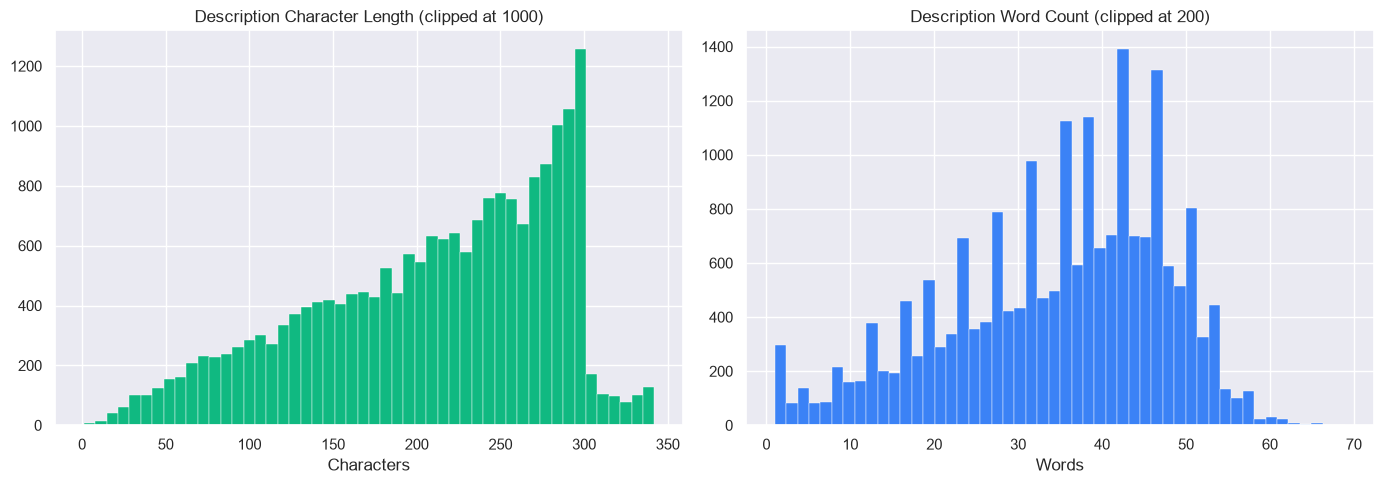

Median description length: 224 chars
Median word count        : 37 words
Very short (<20 chars)   : 53 games

Sample very short descriptions:
['Relive Half-Life.', 'egg', 'Montaro is a DOGE.', 'Seize the day', 'click to ten', 'Minimal puzzle game.', '无限重来，再战江湖，10分钟一局', '高自由度水墨风格武侠', 'GOTY', 'Faster and funnier!']


In [31]:
# ── Description length distribution ───────────────────────────────────────
df['desc_length'] = df['desc_clean'].str.len()
df['desc_word_count'] = df['desc_clean'].str.split().str.len().fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df.loc[df['desc_length'] > 0, 'desc_length'].clip(0, 1000),
             bins=50, color='#10b981', edgecolor='white', linewidth=0.3)
axes[0].set_title('Description Character Length (clipped at 1000)')
axes[0].set_xlabel('Characters')

axes[1].hist(df.loc[df['desc_word_count'] > 0, 'desc_word_count'].clip(0, 200),
             bins=50, color='#3b82f6', edgecolor='white', linewidth=0.3)
axes[1].set_title('Description Word Count (clipped at 200)')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_description_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Median description length: {df.loc[df["desc_length"]>0, "desc_length"].median():.0f} chars')
print(f'Median word count        : {df.loc[df["desc_word_count"]>0, "desc_word_count"].median():.0f} words')
print(f'Very short (<20 chars)   : {(df["desc_length"].between(1, 20)).sum():,} games')

# Show a sample of very short descriptions — they may be noise
print('\nSample very short descriptions:')
print(df.loc[df['desc_length'].between(1, 20), 'desc_clean'].head(10).tolist())

In [32]:
# ── CLEAN UP TEMPORARY COLUMNS ────────────────────────────────────────────────
# These columns were created during exploration and should not persist into
# the working DataFrame that Notebook 02 will use.
df.drop(
    columns=[
        'desc_clean', 'desc_length', 'desc_word_count',  # description exploration
        'genres_parsed', 'genre_count',                   # genre exploration
        'tags_parsed',                                     # tag exploration
        *([c for c in ['cats_parsed'] if 'cats_parsed' in df.columns]),
    ],
    errors='ignore',
    inplace=True
)
print('Temp columns removed. Remaining df columns:')
print(df.columns.tolist())


Temp columns removed. Remaining df columns:
['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count', 'detailed_description', 'about_the_game', 'short_description', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'achievements', 'recommendations', 'notes', 'supported_languages', 'full_audio_languages', 'packages', 'developers', 'publishers', 'categories', 'genres', 'screenshots', 'movies', 'user_score', 'score_rank', 'positive', 'negative', 'estimated_owners', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags', 'pct_pos_total', 'num_reviews_total', 'pct_pos_recent', 'num_reviews_recent', 'positive_ratio', 'reception_label', 'is_free']


## 14. Class Balance Deep Dive

With ~72% positive class, a naive classifier achieves >70% accuracy by always predicting 1.  
This is why **F1 score on the minority class** is our primary metric, not accuracy.


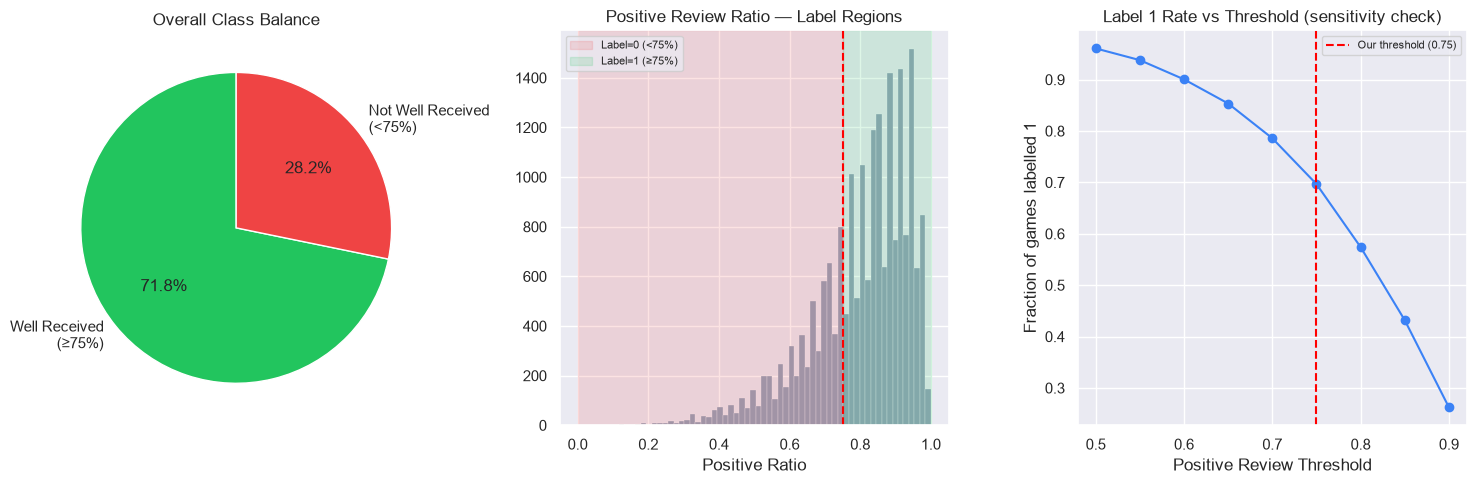

Saved: 01_class_balance.png


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Overall class balance
label_counts = df['reception_label'].value_counts()
axes[0].pie(
    label_counts.values,
    labels=['Well Received\n(≥75%)', 'Not Well Received\n(<75%)'],
    colors=['#22c55e', '#ef4444'],
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Overall Class Balance')

# Positive ratio histogram with label region shading
axes[1].hist(df['positive_ratio'].dropna(), bins=60, color='#94a3b8', edgecolor='white', linewidth=0.2)
axes[1].axvspan(0, 0.75, alpha=0.15, color='#ef4444', label='Label=0 (<75%)')
axes[1].axvspan(0.75, 1.0, alpha=0.15, color='#22c55e', label='Label=1 (≥75%)')
axes[1].axvline(0.75, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Positive Review Ratio — Label Regions')
axes[1].set_xlabel('Positive Ratio')
axes[1].legend(fontsize=8)

# Sensitivity: how does class balance shift with different thresholds?
thresholds = np.arange(0.5, 0.95, 0.05)
pos_rates = []
for t in thresholds:
    rate = (df['positive_ratio'] >= t).mean()
    pos_rates.append(rate)
axes[2].plot(thresholds, pos_rates, 'o-', color='#3b82f6')
axes[2].axvline(0.75, color='red', linestyle='--', linewidth=1.5, label='Our threshold (0.75)')
axes[2].set_xlabel('Positive Review Threshold')
axes[2].set_ylabel('Fraction of games labelled 1')
axes[2].set_title('Label 1 Rate vs Threshold (sensitivity check)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_class_balance.png')

## 15. Feature–Label Correlation

A quick point-biserial correlation between each numerical feature and the binary label.  
This gives an early signal of which features are likely to be most predictive.


In [34]:
from scipy import stats

numeric_feature_cols = [COL_PRICE, COL_DLC, COL_AGE]
# Add platform columns if available
for col in [COL_WIN, COL_MAC, COL_LIN]:
    if col and col in df.columns:
        numeric_feature_cols.append(col)
if COL_IS_FREE and COL_IS_FREE in df.columns:
    numeric_feature_cols.append(COL_IS_FREE)

numeric_feature_cols = [c for c in numeric_feature_cols if c and c in df.columns]

print('=== POINT-BISERIAL CORRELATION WITH LABEL ===')
print(f'{"Feature":<30} {"Correlation":>12} {"p-value":>12} {"Significant?":>14}')
print('-' * 72)

corr_results = []
for col in numeric_feature_cols:
    valid = df[[col, 'reception_label']].dropna()
    if len(valid) < 10 or valid[col].nunique() < 2:
        continue
    r, p = stats.pointbiserialr(valid['reception_label'], valid[col])
    sig = '✓' if p < 0.05 else '✗'
    print(f'{col:<30} {r:>12.4f} {p:>12.4e} {sig:>14}')
    corr_results.append({'feature': col, 'correlation': r, 'p_value': p})

corr_df = pd.DataFrame(corr_results).sort_values('correlation', key=abs, ascending=False)


=== POINT-BISERIAL CORRELATION WITH LABEL ===
Feature                         Correlation      p-value   Significant?
------------------------------------------------------------------------
price                                0.0206   3.2570e-03              ✓
dlc_count                            0.0050   4.7740e-01              ✗
required_age                        -0.0256   2.5194e-04              ✓
windows                              0.0112   1.1074e-01              ✗
mac                                  0.0973   4.5435e-44              ✓
linux                                0.0939   3.4418e-41              ✓
is_free                             -0.0717   1.2117e-24              ✓


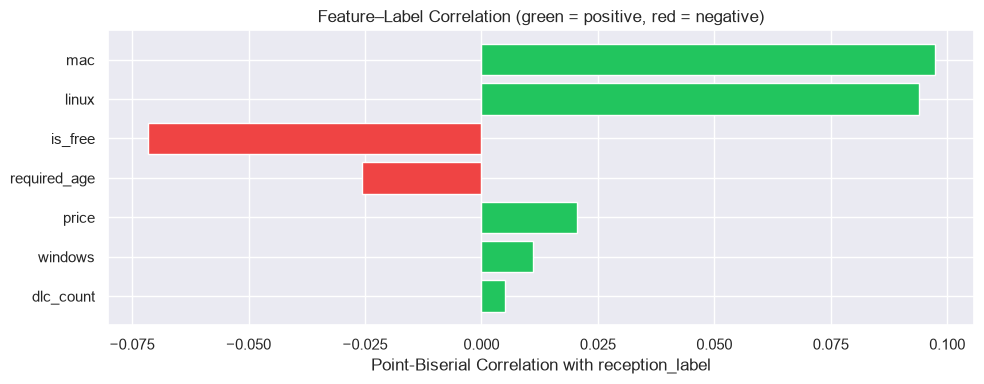

Saved: 01_feature_label_correlation.png


In [35]:
# ── Correlation bar chart ──────────────────────────────────────────────────
if len(corr_df) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(corr_df) * 0.4)))
    colors = ['#22c55e' if r > 0 else '#ef4444' for r in corr_df['correlation']]
    ax.barh(corr_df['feature'][::-1], corr_df['correlation'][::-1], color=colors[::-1])
    ax.axvline(0, color='white', linewidth=0.8)
    ax.set_xlabel('Point-Biserial Correlation with reception_label')
    ax.set_title('Feature–Label Correlation (green = positive, red = negative)')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '01_feature_label_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 01_feature_label_correlation.png')

## 16. Supported Languages

The `supported_languages` column is a string list of language names.  
We convert it to `supported_languages_count` (integer) for use in Tier 3.


In [36]:
COL_LANG = col_map.get('supported_languages') or 'supported_languages'

if COL_LANG in df.columns:
    # Count languages — the column may be a comma-separated string or a list
    def count_languages(val):
        if pd.isna(val) or str(val).strip() in ('', '[]'):
            return 0
        try:
            parsed = ast.literal_eval(str(val))
            return len(parsed) if isinstance(parsed, list) else 1
        except:
            # Count commas as separator
            return len([x for x in str(val).split(',') if x.strip()])

    df['_lang_count'] = df[COL_LANG].apply(count_languages)
    print('Language count statistics:')
    print(df['_lang_count'].describe())
    print(f'\nGames with 0 languages listed: {(df["_lang_count"] == 0).sum():,}')
    print(f'Median language count: {df["_lang_count"].median():.0f}')

    r, p = stats.pointbiserialr(
        df['reception_label'],
        df['_lang_count'].fillna(0)
    )
    print(f'\nCorrelation with label: r={r:.4f}, p={p:.4e}')
    df.drop(columns=['_lang_count'], inplace=True)
else:
    print(f'Column {COL_LANG} not found.')

Language count statistics:
count   20383.0000
mean        6.9414
std        11.4297
min         0.0000
25%         1.0000
50%         4.0000
75%         9.0000
max       103.0000
Name: _lang_count, dtype: float64

Games with 0 languages listed: 44
Median language count: 4

Correlation with label: r=0.0151, p=3.1655e-02


## 17. Findings Summary → Inputs for `config.py`

In [ ]:
# ── FINAL SUMMARY ─────────────────────────────────────────────────────────────
print('=' * 70)
print('NOTEBOOK 01 — DATASET EXPLORATION SUMMARY')
print('=' * 70)

print(f'\nRAW DATASET')
print(f'  Total games              : {len(df_raw):,}')
print(f'  Columns                  : {len(df_raw.columns)}')

print(f'\nAFTER ≥100 REVIEW FILTER (sentinel -1 rows also removed)')
print(f'  Games retained           : {len(df):,}  (22.7% of raw)')
print(f'  Well Received  (label=1) : {df["reception_label"].sum():,}  ({df["reception_label"].mean()*100:.1f}%)')
print(f'  Not Received   (label=0) : {(df["reception_label"]==0).sum():,}  ({(df["reception_label"]==0).mean()*100:.1f}%)')
print(f'  Free-to-play games       : {df["is_free"].sum():,}  ({df["is_free"].mean()*100:.1f}%)')

print(f'\nCOLUMN DECISIONS')
from collections import defaultdict
dc = defaultdict(int)
for info in DECISIONS.values():
    dc[info["decision"].split(" —")[0].split(" (")[0].strip()] += 1
for k, v in sorted(dc.items()):
    print(f'  {k:<20}: {v} columns')

print(f'\nFEATURE TIERS — WHAT GOES INTO EACH MODEL')
print(f'  Tier 1 (Core):')
print(f'    Raw    : price, required_age')
print(f'    One-hot: genre_Indie, genre_Adventure, genre_Action, genre_Casual,')
print(f'             genre_Simulation, genre_RPG, genre_Strategy, genre_Free_To_Play,')
print(f'             genre_Early_Access, genre_Massively_Multiplayer')
print(f'    Derived: genre_concentration = genres_assigned / 10')
print()
print(f'  Tier 2 (+ Monetisation):')
print(f'    Derived: is_free (price==0), price_to_dlc_ratio = price/(dlc_count+1)')
print()
print(f'  Tier 3 (+ Content):')
print(f'    One-hot: top 20 tags, key categories incl. In-App_Purchases (43.2% reception — most discriminative category)')
print(f'    Derived: platform_coverage = (mac + linux) / 2  [windows DROPPED — zero variance]')
print(f'             supported_languages_count (parsed from supported_languages, r=+0.015 ✓)')
print(f'             screenshot_count (parsed from screenshots, r=-0.060 ✓ negative)')
print(f'             movie_count (parsed from movies, r=-0.021 ✓ negative)')
print(f'             has_website (binary from website, r=-0.021 ✓ negative)')
print(f'             has_achievements (binary: achievements>0, r confirmed significant ✓)')
print(f'    DROPPED: full_audio_languages_count (r=0.008, p=0.277 — not significant)')
print(f'    NOTE   : required_age has -1 sentinel values → fix with clip(0,18) in notebook 02')
print()
print(f'  Tier 5 (+ NLP):')
print(f'    Source : short_description → SBERT (all-MiniLM-L6-v2) → PCA(50 dims)')
print(f'    Fallback: 37 games with no description → route to Model D')

print(f'\nKEY FINDINGS FROM CORRELATION ANALYSIS')
print(f'  Strongest signals  : mac (r=+0.097), linux (r=+0.094)')
print(f'  Strongest negative : is_free (r=-0.072)')
print(f'  Weak but significant: required_age (r=-0.026), price (r=+0.021), supported_languages (r=+0.015)')
print(f'  Dropped (insignificant): windows (r=0.011, p=0.111), dlc_count (r=0.005, p=0.477)')
print(f'  Dropped (insignificant): full_audio_languages_count (r=0.008, p=0.277)')
print(f'  Negative correlations  : screenshot_count (r=-0.060), movie_count (r=-0.021), has_website (r=-0.021)')
print(f'  Massively Multiplayer  : only 36.2% well-received (vs 71.8% baseline) — most discriminative genre')
print(f'  In-App Purchases cat   : only 43.2% well-received — most discriminative category')
print(f'  platform_coverage      : r=0.107 — strongest feature in dataset (stronger than mac/linux alone)')
print(f'  has_achievements binary: 0 achiev=64.7% vs >0=74.4% well-received (10pp gap)')

print(f'\nCOLUMN NAMES CONFIRMED FOR config.py')
for k, v in col_map.items():
    if v and k not in ['app_id', 'name', 'release_date', 'developers', 'publishers', 'windows']:
        print(f'  {k:<25} → {v}')

print(f'\nTOP 10 GENRES → one-hot features in Tier 1:')
for i, g in enumerate(TOP_10_GENRES, 1):
    print(f'  {i:>2}. genre_{g.replace(" ", "_").replace("-", "_")}')

print(f'\nTOP 20 TAGS → one-hot features in Tier 3:')
for i, t in enumerate(TOP_20_TAGS, 1):
    print(f'  {i:>2}. tag_{t.replace(" ", "_").replace("-", "_")}')

#print(f'\nACTION ITEMS BEFORE NOTEBOOK 02:')
#print(f'  1. Copy confirmed column names above into src/config.py')
#print(f'  2. Copy TOP_10_GENRES and TOP_20_TAGS into TIER1_FEATURES / TIER3_FEATURES in config.py')
#print(f'  3. Confirm new feature correlations (section 11b) — drop any with p > 0.05')
#print(f'  4. Do Kernel → Restart & Run All one final time to confirm clean top-to-bottom run')
print('=' * 70)


NOTEBOOK 01 — DATASET EXPLORATION SUMMARY

RAW DATASET
  Total games              : 89,618
  Columns                  : 47

AFTER ≥100 REVIEW FILTER (sentinel -1 rows also removed)
  Games retained           : 20,383  (22.7% of raw)
  Well Received  (label=1) : 14,631  (71.8%)
  Not Received   (label=0) : 5,752  (28.2%)
  Free-to-play games       : 4,268  (20.9%)

COLUMN DECISIONS
  DROP                : 31 columns
  FILTER ONLY         : 1 columns
  KEEP                : 15 columns
  LABEL SOURCE        : 1 columns

FEATURE TIERS — WHAT GOES INTO EACH MODEL
  Tier 1 (Core):
    Raw    : price, required_age
    One-hot: genre_Indie, genre_Adventure, genre_Action, genre_Casual,
             genre_Simulation, genre_RPG, genre_Strategy, genre_Free_To_Play,
             genre_Early_Access, genre_Massively_Multiplayer
    Derived: genre_concentration = genres_assigned / 10

  Tier 2 (+ Monetisation):
    Derived: is_free (price==0), price_to_dlc_ratio = price/(dlc_count+1)

  Tier 3 (+ Cont